## ✅ Import Libs

In [1]:
import re

import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from datasist.structdata import detect_outliers

import warnings


from sklearn.compose import ColumnTransformer , TransformedTargetRegressor
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, MinMaxScaler, RobustScaler, StandardScaler,PowerTransformer
from category_encoders import TargetEncoder, BinaryEncoder
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_selection import SelectFromModel

# Linear Models
from sklearn.linear_model import LinearRegression, Ridge, PassiveAggressiveRegressor

# Tree Models
from sklearn.tree import DecisionTreeRegressor

# Ensemble Models
from sklearn.ensemble import (
    RandomForestRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor,
    IsolationForest
)

# Boosting
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# Naive Bayes (Not valid for regression → removed)

# Neighbors
from sklearn.neighbors import KNeighborsRegressor

# SVM
from sklearn.svm import SVR, LinearSVR

# Neural Network
from sklearn.neural_network import MLPRegressor

# Metrics for Regression
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error,
    make_scorer
)

import joblib
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=UserWarning)

from sklearn.model_selection import cross_validate, train_test_split

# Time-Series Aware CV
from sklearn.model_selection import TimeSeriesSplit

# TensorFlow & Keras for ANN
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from scikeras.wrappers import KerasRegressor

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans 
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.manifold import TSNE

## ✅ Set-config

In [2]:
pd.set_option('display.max_columns', None)

warnings.filterwarnings('ignore')

# Phase 2️:Data Loading & Exploaring
**Steps:**
- ✅ Load and Check info
- ✅ Check Nulls
- ✅ Check Duplicates

## ✅ Load and Check info

In [3]:
df = pd.read_csv("../data/egypt_real_estate_listings.csv")

In [4]:
df.head()

,url,price,description,location,type,size,bedrooms,bathrooms,available_from,payment_method,down_payment
0,https://www.propertyfinder.eg/en/plp/buy/chale...,"8,000,000",OWN A CHALET IN EL GOUNA WITH A PRIME LOCATION...,"Swan Lake Gouna, Al Gouna, Hurghada, Red Sea",Chalet,732 sqft / 68 sqm,1+ Maid,1,31-Aug-25,Cash,"1,200,000 EGP"
1,https://www.propertyfinder.eg/en/plp/buy/villa...,"25,000,000","For sale, a villa with immediate delivery in C...","Karmell, New Zayed City, Sheikh Zayed City, Giza",Villa,"2,368 sqft / 220 sqm",4,4,2-Sep-25,Cash,"2,100,000 EGP"
2,https://www.propertyfinder.eg/en/plp/buy/chale...,"15,135,000","With a down payment of EGP 1,513,000, a fully ...","Azha North, Ras Al Hekma, North Coast",Chalet,"1,270 sqft / 118 sqm",2,2,19-Aug-25,Cash,"1,513,000 EGP"
3,https://www.propertyfinder.eg/en/plp/buy/apart...,"12,652,000",Own an apartment in New Cairo with a minimal d...,"Taj City, 5th Settlement Compounds, The 5th Se...",Apartment,"1,787 sqft / 166 sqm",3,2,26-Aug-25,Installments,"1,260,000 EGP"
4,https://www.propertyfinder.eg/en/plp/buy/villa...,"45,250,000",Project: Granville\nLocation: Fifth Settlement...,"Granville, New Capital City, Cairo",Villa,"4,306 sqft / 400 sqm",7,7,2-Sep-25,Cash,"2,262,500 EGP"


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19924 entries, 0 to 19923
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   url             19924 non-null  object
 1   price           19385 non-null  object
 2   description     19846 non-null  object
 3   location        19833 non-null  object
 4   type            19847 non-null  object
 5   size            19847 non-null  object
 6   bedrooms        19780 non-null  object
 7   bathrooms       19784 non-null  object
 8   available_from  19261 non-null  object
 9   payment_method  19383 non-null  object
 10  down_payment    5445 non-null   object
dtypes: object(11)
memory usage: 1.7+ MB


In [6]:
df['bathrooms'].unique(),df['bathrooms'].nunique()

(array(['1', '4', '2', '7', '5', '3', '6', '7+', nan, 'none'], dtype=object),
 9)

In [7]:
df['bedrooms'].unique(),df['bedrooms'].nunique()

(array(['1+ Maid', '4', '2', '3', '7', '5+ Maid', '3+ Maid', '2+ Maid',
        '1', '4+ Maid', '7+ Maid', 'studio', '5', '6+ Maid', nan,
        'studio+ Maid', '7++ Maid', '7+', '6'], dtype=object),
 18)

In [8]:
df['price'].unique(),df['price'].nunique()

(array(['8,000,000', '25,000,000', '15,135,000', ..., '5,704,000',
        '7,340,006', '350,000'], shape=(4287,), dtype=object),
 4286)

In [9]:
df['size'].unique(),df['size'].nunique()

(array(['732 sqft / 68 sqm', '2,368 sqft / 220 sqm',
        '1,270 sqft / 118 sqm', '1,787 sqft / 166 sqm',
        '4,306 sqft / 400 sqm', '1,356 sqft / 126 sqm',
        '2,820 sqft / 262 sqm', '3,983 sqft / 370 sqm',
        '2,099 sqft / 195 sqm', '807 sqft / 75 sqm',
        '1,507 sqft / 140 sqm', '1,722 sqft / 160 sqm',
        '797 sqft / 74 sqm', '1,378 sqft / 128 sqm', '689 sqft / 64 sqm',
        '1,615 sqft / 150 sqm', '775 sqft / 72 sqm',
        '1,345 sqft / 125 sqm', '1,830 sqft / 170 sqm',
        '1,076 sqft / 100 sqm', '1,582 sqft / 147 sqm',
        '840 sqft / 78 sqm', '2,583 sqft / 240 sqm',
        '2,013 sqft / 187 sqm', '484 sqft / 45 sqm',
        '1,647 sqft / 153 sqm', '2,002 sqft / 186 sqm',
        '1,098 sqft / 102 sqm', '2,799 sqft / 260 sqm',
        '635 sqft / 59 sqm', '4,338 sqft / 403 sqm', '764 sqft / 71 sqm',
        '1,119 sqft / 104 sqm', '1,023 sqft / 95 sqm',
        '1,496 sqft / 139 sqm', '2,809 sqft / 261 sqm',
        '915 sqft / 85 sqm',

## ✅ Check Nulls

In [10]:
(df.isnull().sum().sort_values(ascending=False))/df.shape[0]*100

down_payment      72.671150
available_from     3.327645
payment_method     2.715318
price              2.705280
bedrooms           0.722746
bathrooms          0.702670
location           0.456736
description        0.391488
size               0.386469
type               0.386469
url                0.000000
dtype: float64

## ✅ Check Duplicates

In [11]:
df.drop(['url','down_payment'],axis=1,inplace=True)
df.duplicated().sum()

np.int64(178)

# Phase 3️: Data Cleaning

Steps:

*   ✅ Data Cleaning
      1.   Fix Data Type
      2.   Drop Duplicated
      3.   Dealing With Missing Values

## ✅ Data Cleaning

#### 1. Fix Data Type

In [12]:
# Fix Price Column
df['price'] = df['price'].str.replace(',','').astype(float)

In [13]:
# create new column
df['is_bathrooms_7plus'] = df['bathrooms'].apply(lambda x: 1 if x == '7+' else 0)
# fix data type for bathrooms
df['bathrooms'] = pd.to_numeric(df['bathrooms'].apply(
    lambda x: 7 if x == '7+' else (np.nan if x == 'none' else x)
),errors='coerce')

In [14]:
# create ne columns
df['studio_flag'] = df['bedrooms'].str.contains('studio', case=False, na=False).astype(int)
df['maid_room'] = df['bedrooms'].str.contains('Maid', case=False, na=False).astype(int)
df['bedrooms_7plus_flag'] = df['bedrooms'].str.contains('7\+', na=False).astype(int)

# fix data type for bedrooms
def clean_bedrooms(x):
    if pd.isna(x):
        return np.nan

    x = x.lower()

    if 'studio' in x:
        return 0
    elif '7+' in x:
        return 7
    else:
        return int(x.split('+')[0].strip())


df['bedrooms'] = df['bedrooms'].apply(clean_bedrooms)

In [15]:
def size_m(x):
  try:
    m = x.split('/')[1].split(' ')[1]
    m = m.replace(",",'')
    return float(m)
  except:
    return x
df['size_metters'] = df['size'].apply(size_m)
df.drop('size',axis=1,inplace=True)

In [16]:
df['available_from'] = pd.to_datetime(df['available_from'])

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19924 entries, 0 to 19923
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   price                19385 non-null  float64       
 1   description          19846 non-null  object        
 2   location             19833 non-null  object        
 3   type                 19847 non-null  object        
 4   bedrooms             19780 non-null  float64       
 5   bathrooms            19779 non-null  float64       
 6   available_from       19261 non-null  datetime64[ns]
 7   payment_method       19383 non-null  object        
 8   is_bathrooms_7plus   19924 non-null  int64         
 9   studio_flag          19924 non-null  int64         
 10  maid_room            19924 non-null  int64         
 11  bedrooms_7plus_flag  19924 non-null  int64         
 12  size_metters         19847 non-null  float64       
dtypes: datetime64[ns](1), float64(4

#### 2. Drop Duplicated

In [18]:
df.drop_duplicates(inplace=True)
df.reset_index(drop=True,inplace=True)

#### 3. Dealing With Missing Values

In [19]:
df.isnull().sum().sort_values(ascending=False)

available_from         584
payment_method         463
price                  461
bathrooms               55
bedrooms                54
location                15
description              2
type                     1
size_metters             1
is_bathrooms_7plus       0
studio_flag              0
maid_room                0
bedrooms_7plus_flag      0
dtype: int64

In [20]:
for i in range(10):
  print(df[df['price'].isna()].reset_index(drop=True)['description'][i])
  print("#"*100)

Silver Sands in Sidi Heneish, North Coast is an artwork by Ora
Penthouse chalet
Building G+1
223 + 58 m roof
1 master bedroom
2 bedrooms
1 nanny's room with private bathroom
Down payment 17.5 m
The rest 2.2 million over 3 years
Delivery 2026
Fully finished
Silver Sands in Sidi Heneish, North Coast is an artwork by Ora Developers rolling over 506 acres (2,112,600 SQM) of land. The project is created to be a summer resort, an easy-peasy weekend destination, and an all-year-season gateway.
Nightlife venues
Swimming pools
1.2 km tree-lined spine & vast verdant landscapes
Swimmable lagoons stretched across 88,000 SQM
Health & wellness facilities including luxurious spas
Open-air cinema
Sports facilities including multipurpose courts and well-equipped gyms
Besides the world-class facilities, Silver Sands North Coast is home to a notable selection of properties scattered across different phases of development.
###################################################################################

In [21]:
nulls_price = df[df['price'].isna()].reset_index(drop=True)

In [22]:
def extract_final_price(text):

    if pd.isna(text):
        return np.nan

    text = str(text).lower()

    def normalize(num, unit=''):
        if not num:
            return np.nan

        num = num.replace(',', '').replace('.', '')

        if not num.isdigit():
            return np.nan

        value = float(num)

        if unit in ['m', 'million']:
            value *= 1_000_000

        return value

    # 1️⃣ TRY DIRECT TOTAL PRICE
    total_patterns = [
        r'total price[:\s]*([\d\.,]+)\s*(m|million)?',
        r'price[:\s]*([\d\.,]+)\s*(m|million)?',
        r'السعر الإجمالى[:\s]*([\d\.,]+)',
        r'([\d\.,]+)\s*(m|million)\s*egp',
        r'([\d\.,]+)\s*egp'
    ]

    total = np.nan

    for p in total_patterns:
        m = re.search(p, text)
        if m:
            groups = m.groups()
            num = groups[0]
            unit = groups[1] if len(groups) > 1 and groups[1] else ''
            total = normalize(num, unit)
            if not pd.isna(total):
                return total  # ✅ STOP EARLY (best case)

    # 2️⃣ TRY DOWN PAYMENT
    down = np.nan
    down_patterns = [
        r'down payment[:\s]*([\d\.,]+)\s*(m|million)?',
        r'مقدم[:\s]*([\d\.,]+)'
    ]

    for p in down_patterns:
        m = re.search(p, text)
        if m:
            groups = m.groups()
            num = groups[0]
            unit = groups[1] if len(groups) > 1 and groups[1] else ''
            down = normalize(num, unit)
            break

    # 3️⃣ TRY REMAINING
    remain = np.nan
    remain_patterns = [
        r'remaining[:\s]*([\d\.,]+)\s*(m|million)?',
        r'the rest[:\s]*([\d\.,]+)\s*(m|million)?',
        r'المتبقي[:\s]*([\d\.,]+)'
    ]

    for p in remain_patterns:
        m = re.search(p, text)
        if m:
            groups = m.groups()
            num = groups[0]
            unit = groups[1] if len(groups) > 1 and groups[1] else ''
            remain = normalize(num, unit)
            break

    # 4️⃣ FALLBACK: SUM COMPONENTS
    if not pd.isna(down) and not pd.isna(remain):
        return down + remain

    return np.nan

In [23]:
nulls_price['price'] = nulls_price['description'].apply(extract_final_price)

In [24]:
filled = df['price'].isnull().sum() - nulls_price['price'].isna().sum()
remaining_nulls = nulls_price['price'].isna().sum()

print(f"Now we filled prices for {filled} units.")
print(f"Now total nulls in price column: {remaining_nulls}")

Now we filled prices for 104 units.
Now total nulls in price column: 357


In [25]:
# new Data
data = pd.concat((df.dropna(subset='price'),nulls_price.dropna(subset='price')),axis=0).reset_index(drop=True)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19389 entries, 0 to 19388
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   price                19389 non-null  float64       
 1   description          19388 non-null  object        
 2   location             19380 non-null  object        
 3   type                 19389 non-null  object        
 4   bedrooms             19338 non-null  float64       
 5   bathrooms            19337 non-null  float64       
 6   available_from       18834 non-null  datetime64[ns]
 7   payment_method       19283 non-null  object        
 8   is_bathrooms_7plus   19389 non-null  int64         
 9   studio_flag          19389 non-null  int64         
 10  maid_room            19389 non-null  int64         
 11  bedrooms_7plus_flag  19389 non-null  int64         
 12  size_metters         19389 non-null  float64       
dtypes: datetime64[ns](1), float64(4

In [26]:
data.isnull().sum().sort_values(ascending=False)

available_from         555
payment_method         106
bathrooms               52
bedrooms                51
location                 9
description              1
price                    0
type                     0
is_bathrooms_7plus       0
studio_flag              0
maid_room                0
bedrooms_7plus_flag      0
size_metters             0
dtype: int64

In [27]:
def extract_payment_method(text):
    if pd.isna(text):
        return np.nan

    text = str(text).lower()

    # Cash patterns
    cash_patterns = [
        r'\bcash\b',
        r'\bكاش\b'
    ]

    # Installment patterns
    installment_patterns = [
        r'installment',
        r'installments',
        r'flexible payment',
        r'تقسيط'
    ]

    for p in cash_patterns:
        if re.search(p, text):
            return 'Cash'

    for p in installment_patterns:
        if re.search(p, text):
            return 'Installments'

    return np.nan

In [28]:
data[data['payment_method'].isnull()]['description'].apply(extract_payment_method).isnull().sum()

np.int64(67)

In [29]:
mask = data['payment_method'].isnull()
data.loc[mask, 'payment_method'] = data.loc[mask, 'description'].apply(extract_payment_method)

In [30]:
data.isnull().sum().sort_values(ascending=False)

available_from         555
payment_method          67
bathrooms               52
bedrooms                51
location                 9
description              1
price                    0
type                     0
is_bathrooms_7plus       0
studio_flag              0
maid_room                0
bedrooms_7plus_flag      0
size_metters             0
dtype: int64

In [31]:
# also we can make another def for bath and bedrooms but i will not.
# and i don't want to fill this rows with un real data, so i will remove it.
# but i will deal with the date in another way:
#   1.Keep rows
#   2.Extract year/month/week
#   3. Add date_missing flag
#   4. Median impute
# now, we will moving to EDA 
data.dropna(subset=['payment_method','bathrooms','bedrooms','location'],inplace=True)
data.drop('description',axis=1,inplace=True)
data.reset_index(drop=True,inplace=True)

In [32]:
data

,price,location,type,bedrooms,bathrooms,available_from,payment_method,is_bathrooms_7plus,studio_flag,maid_room,bedrooms_7plus_flag,size_metters
0,8000000.0,"Swan Lake Gouna, Al Gouna, Hurghada, Red Sea",Chalet,1.0,1.0,2025-08-31,Cash,0,0,1,0,68.0
1,25000000.0,"Karmell, New Zayed City, Sheikh Zayed City, Giza",Villa,4.0,4.0,2025-09-02,Cash,0,0,0,0,220.0
2,15135000.0,"Azha North, Ras Al Hekma, North Coast",Chalet,2.0,2.0,2025-08-19,Cash,0,0,0,0,118.0
3,12652000.0,"Taj City, 5th Settlement Compounds, The 5th Se...",Apartment,3.0,2.0,2025-08-26,Installments,0,0,0,0,166.0
4,45250000.0,"Granville, New Capital City, Cairo",Villa,7.0,7.0,2025-09-02,Cash,0,0,0,0,400.0
...,...,...,...,...,...,...,...,...,...,...,...,...
19263,24000000.0,"Mountain View October Park, 6th District, 6 Oc...",Townhouse,3.0,3.0,2025-09-02,Installments,0,0,1,0,232.0
19264,2600000.0,"Stone Park, 5th Settlement Compounds, The 5th ...",Townhouse,4.0,4.0,2025-09-02,Installments,0,0,1,0,235.0
19265,29974880.0,"Hills of one, New Zayed City, Sheikh Zayed Cit...",Villa,4.0,3.0,2025-09-01,Cash,0,0,0,0,265.0
19266,4000000.0,"Stone Park, 5th Settlement Compounds, The 5th ...",Villa,4.0,3.0,2025-08-31,Cash,0,0,1,0,244.0


# Phase 4️: Exploratory Data Analysis
**Steps:**

*   ✅ General Overview
      1. Descriptive stats
      2. Outliers Detection
      3. Skew
*   ✅ Target Analysis
      1. Distribution
      2. Box plot
      3. Kolmogorov–Smirnov  (large data)
*   ✅ Features Analysis
      1. Numeric Features
      2. Categorical Features

## ✅ General Overview

### 1. Descriptive stats

In [33]:
data.describe().T

,count,mean,min,25%,50%,75%,max,std
price,19268.0,16428095.060826,186900.0,6000000.0,10400000.0,18296475.0,840000000.0,23599968.984546
bedrooms,19268.0,2.957858,0.0,2.0,3.0,3.0,7.0,1.160807
bathrooms,19268.0,2.93414,1.0,2.0,3.0,4.0,7.0,1.279845
available_from,18723,2025-08-21 12:56:34.071462912,2023-06-14 00:00:00,2025-08-19 00:00:00,2025-08-31 00:00:00,2025-09-01 00:00:00,2027-10-31 00:00:00,NaN
is_bathrooms_7plus,19268.0,0.007525,0.0,0.0,0.0,0.0,1.0,0.086424
studio_flag,19268.0,0.016919,0.0,0.0,0.0,0.0,1.0,0.128972
maid_room,19268.0,0.46611,0.0,0.0,0.0,1.0,1.0,0.498863
bedrooms_7plus_flag,19268.0,0.010432,0.0,0.0,0.0,0.0,1.0,0.101605
size_metters,19268.0,1035.724777,1.0,126.0,170.0,238.0,15811692.0,113910.19616


In [34]:
data.describe(include="O").T

,count,unique,top,freq
location,19268,1525,"Marassi, Sidi Abdel Rahman, North Coast",417
type,19268,14,Apartment,8263
payment_method,19268,2,Cash,15405


### 2. Outliers Detection

In [35]:
Q1 = data['price'].quantile(0.25)
Q3 = data['price'].quantile(0.75)
IQR = Q3-Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [36]:
data[data['price'] < lower_bound]

,price,location,type,bedrooms,bathrooms,available_from,payment_method,is_bathrooms_7plus,studio_flag,maid_room,bedrooms_7plus_flag,size_metters


In [37]:
data[data['price'] > upper_bound]

,price,location,type,bedrooms,bathrooms,available_from,payment_method,is_bathrooms_7plus,studio_flag,maid_room,bedrooms_7plus_flag,size_metters
4,45250000.0,"Granville, New Capital City, Cairo",Villa,7.0,7.0,2025-09-02,Cash,0,0,0,0,400.0
35,71500000.0,"Belle Vie, New Zayed City, Sheikh Zayed City, ...",Villa,7.0,5.0,2025-08-17,Installments,0,0,1,1,403.0
64,39200000.0,"Ogami, Ras Al Hekma, North Coast",Villa,4.0,4.0,2025-09-02,Installments,0,0,1,0,301.0
83,60000000.0,"Soul North Coast, Qesm Ad Dabaah, North Coast",Villa,4.0,4.0,2025-08-25,Cash,0,0,1,0,800.0
85,60000000.0,"Ramla Lakeside, Qesm Ad Dabaah, North Coast",Villa,5.0,5.0,2025-08-31,Cash,0,0,1,0,670.0
...,...,...,...,...,...,...,...,...,...,...,...,...
19233,37764285.0,"Soul North Coast, Qesm Ad Dabaah, North Coast",Townhouse,3.0,4.0,2025-08-28,Installments,0,0,1,0,193.0
19234,70000000.0,"Touristic 1, Northern Expansions, 6 October Ci...",Villa,7.0,7.0,2025-08-30,Cash,1,0,1,1,1305.0
19244,37446792.0,"Solana, New Zayed City, Sheikh Zayed City, Giza",Villa,4.0,5.0,2025-09-01,Cash,0,0,1,0,337.0
19250,56477000.0,"Soul North Coast, Qesm Ad Dabaah, North Coast",Villa,3.0,3.0,2025-08-31,Installments,0,0,1,0,341.0


### 3. Skew

In [38]:
for col in data.select_dtypes(include='number').columns:
    print(f"skew for {col} column is:{data[col].skew()}")

skew for price column is:8.988317239676132
skew for bedrooms column is:0.5103196870861961
skew for bathrooms column is:0.7807975919764698
skew for is_bathrooms_7plus column is:11.397831708370346
skew for studio_flag column is:7.492012023334388
skew for maid_room column is:0.13588460941625446
skew for bedrooms_7plus_flag column is:9.637722771039996
skew for size_metters column is:138.80111977329264


## ✅ Target Analysis

### 1. Distribution

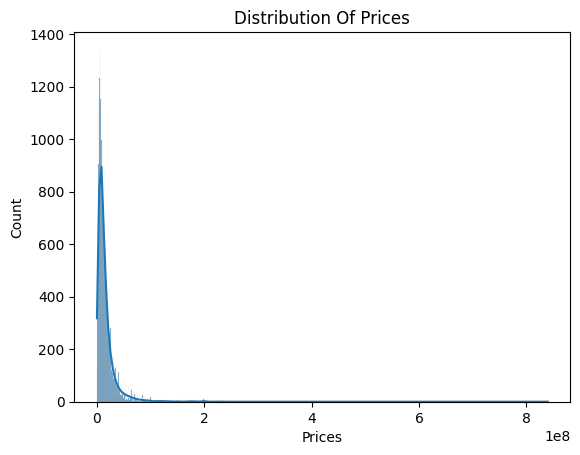

In [39]:
plt.Figure(figsize=(10,18))
sns.histplot(x = data['price'],kde=True)
plt.xlabel("Prices")
plt.title('Distribution Of Prices')
plt.show()

### 2. Box plot

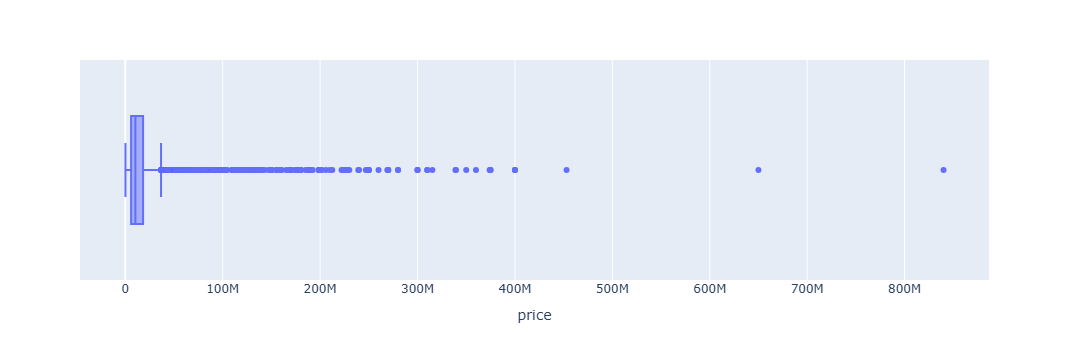

In [40]:
fig = px.box(data,x = 'price')
fig.show()

### 3. Kolmogorov–Smirnov

In [41]:
from scipy.stats import kstest
import numpy as np

price = data['price'].dropna()
price_std = (price - price.mean()) / price.std()

stat, p_value = kstest(price_std, 'norm')

print("KS Statistic:", stat)
print("p-value:", p_value)

KS Statistic: 0.25274922938365585
p-value: 0.0


## ✅ Feature Analysis

### 1. Numeric Features

#### Correlation Matrix

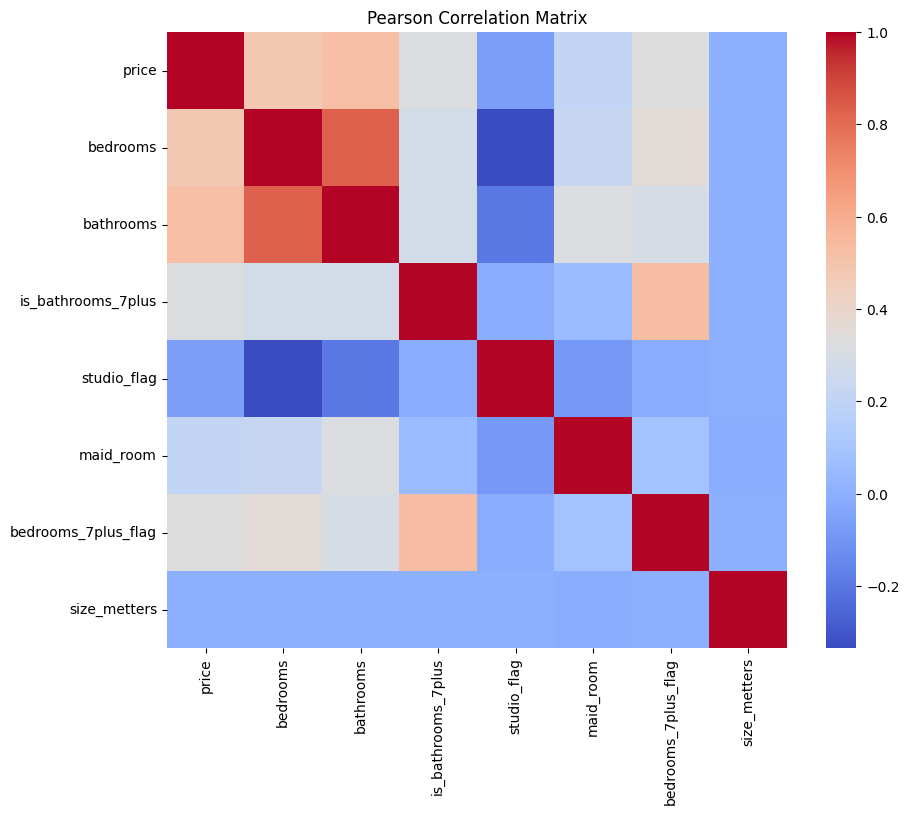

In [42]:
corr_matrix = data.corr(method='pearson',numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False)
plt.title("Pearson Correlation Matrix")
plt.show()

#### Multicollinearity

In [43]:
from statsmodels.stats.outliers_influence import variance_inflation_factor


# Step 1: select numeric columns only
numeric_cols = data.select_dtypes(include=['number']).columns

# Step 2: drop target + non-numeric date columns
X_vif = data[numeric_cols].drop(columns=['price'], errors='ignore')

# Step 3: convert all to float
X_vif = X_vif.astype(float)

# Step 4: compute VIF
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print(vif_data.sort_values(by="VIF", ascending=False))

               Feature        VIF
1            bathrooms  22.462533
0             bedrooms  21.017813
4            maid_room   2.081579
5  bedrooms_7plus_flag   1.451462
2   is_bathrooms_7plus   1.432689
3          studio_flag   1.036690
6         size_metters   1.000132


### 2. Categorical Features

In [44]:
data.select_dtypes(include='object').columns

Index(['location', 'type', 'payment_method'], dtype='object')

In [45]:
data['location'].value_counts().head(25)

location
Marassi, Sidi Abdel Rahman, North Coast                                                         417
Mountain View iCity, 5th Settlement Compounds, The 5th Settlement, New Cairo City, Cairo        387
Madinaty, Cairo                                                                                 356
Hyde Park, 5th Settlement Compounds, The 5th Settlement, New Cairo City, Cairo                  351
Palm Hills New Cairo, 5th Settlement Compounds, The 5th Settlement, New Cairo City, Cairo       319
Silver Sands, Qesm Marsa Matrouh, North Coast                                                   281
O West, 6 October Compounds, 6 October City, Giza                                               280
Sarai, Mostakbal City Compounds, Mostakbal City - Future City, Cairo                            261
Mountain View iCity October, 6 October Compounds, 6 October City, Giza                          255
Mivida, 5th Settlement Compounds, The 5th Settlement, New Cairo City, Cairo                

In [46]:
data['payment_method'].value_counts()

payment_method
Cash            15405
Installments     3863
Name: count, dtype: int64

In [47]:
data['type'].value_counts()

type
Apartment          8263
Chalet             3926
Villa              3392
Townhouse          1277
Twin House          796
Duplex              610
Penthouse           559
iVilla              261
Hotel Apartment     101
Cabin                36
Palace               23
Whole Building       14
Roof                  6
Full Floor            4
Name: count, dtype: int64

In [48]:
from scipy.stats import kruskal

cat_cols = data.select_dtypes(include='object').columns

results = []

for col in cat_cols:
    df = data[[col, 'price']].dropna()
    groups = [g['price'].values for _, g in df.groupby(col)]
    
    if len(groups) > 1:
        stat, p = kruskal(*groups)
        results.append((col, p))

results_df = pd.DataFrame(results, columns=['feature','p_value']).sort_values('p_value')
results_df

,feature,p_value
0,location,0.000000e+00
1,type,0.000000e+00
2,payment_method,1.071928e-08


# Phase 5: Feature Engineering and Preprocessing

## ✅ Feature Eng

### 1. Time Features

In [49]:
data['year'] = data['available_from'].dt.year
data['month'] = data['available_from'].dt.month
data['date_mis'] = data['available_from'].isna().astype(int)

In [50]:
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

data['season'] = data['month'].map(get_season)

### 2. Location Features

In [51]:
def location_features(df, col='location', max_levels=4):
    def _split_one(x):
        if pd.isna(x):
            return [np.nan] * max_levels
        
        parts = [p.strip() for p in str(x).split(',')]
        parts = parts[::-1]
        parts += [np.nan] * (max_levels - len(parts))
        parts = parts[:max_levels]
        return parts[::-1]

    split_cols = df[col].apply(_split_one).apply(pd.Series)

    split_cols.columns = [
        'compound',
        'district',
        'city',
        'governorate'
    ][:max_levels]

    return pd.concat([df, split_cols], axis=1)

data = location_features(data, col='location')

### 3. Aggregations

In [52]:
agg = data.groupby('location')['size_metters'].agg(['mean', 'median', 'std'])

data['Location_Rank'] = data['location'].map(agg['mean'].rank(pct=True))
data['Location_Size_mean'] = data['location'].map(agg['mean'])

### 4. Derived features

In [53]:
data['Relative_Size'] = data['size_metters'] / data['Location_Size_mean']
data['Size_per_room'] = data['size_metters'] / (data['bedrooms'] + data['bathrooms'])

data['high_luxury_flag'] = (
    data['bedrooms_7plus_flag'] | data['is_bathrooms_7plus']
).astype(int)

data['luxury_score'] = (
    data['bedrooms_7plus_flag'] + data['is_bathrooms_7plus']
)

data['Small_unit'] = (
    (data['studio_flag'] == 1) | (data['bedrooms'] <= 1)
).astype(int)

### 5. Type

In [54]:
rare_types = [
    'iVilla', 'Hotel Apartment', 'Cabin',
    'Palace', 'Whole Building', 'Roof', 'Full Floor'
]

data['type'] = data['type'].replace(rare_types, 'Other')

In [55]:
# Drop original date
data = data.drop("available_from", axis=1)

## ✅ Preprocessing

### 1️⃣ X,y

In [56]:
data = data.dropna()

X = data.drop("price",axis=1)
y = data['price']

### 2️⃣ Columns Transformer

In [57]:
cats_cols = X.select_dtypes(include=["object", "category"])
num_cols = X.select_dtypes(include=["number"]).columns.tolist()

high_skew_cols = [col for col in num_cols if data[col].skew() > 2]

# Split categories
onehot_cols = [col for col in cats_cols if 2 < data[col].nunique() < 10]
binary_cols = [col for col in cats_cols if data[col].nunique() == 2]
target_cols = [col for col in cats_cols if data[col].nunique() > 10]

In [58]:
onehot_cols

['type', 'season']

In [59]:
binary_cols

['payment_method']

In [60]:
target_cols

['location', 'compound', 'district', 'city']

In [61]:
num_pipeline = Pipeline([
    ("skew", PowerTransformer(method='yeo-johnson')),
    ("scaler", RobustScaler())
])


cat_pipeline = ColumnTransformer([
    ('onehot', OneHotEncoder(handle_unknown='ignore'), onehot_cols),
    ('binary', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), binary_cols),
    ('target', TargetEncoder(), target_cols)
])


Preprocessing = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, onehot_cols + binary_cols + target_cols)
], remainder='drop')

## ✅ ModelMaker

### 1. Pipeline def

In [62]:
def Modelmaker(model=None, ANN=False):
    steps = [
        ("Preprocessing",Preprocessing),
        ("Feature Selection",SelectFromModel(
             estimator=ExtraTreesRegressor(
                 n_estimators=600,
                 max_features=0.90,
                 random_state=42,
                 min_samples_leaf=5,
                 min_samples_split=10,
                 n_jobs=-1
             ),
             threshold="median"
         )),
        ("Regressor", model)
    ]

    model = Pipeline(steps)
    return model

## ✅ Train & Test Split

In [63]:
X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42)

X_train.columns

Index(['location', 'type', 'bedrooms', 'bathrooms', 'payment_method',
       'is_bathrooms_7plus', 'studio_flag', 'maid_room', 'bedrooms_7plus_flag',
       'size_metters', 'year', 'month', 'date_mis', 'season', 'compound',
       'district', 'city', 'governorate', 'Location_Rank',
       'Location_Size_mean', 'Relative_Size', 'Size_per_room',
       'high_luxury_flag', 'luxury_score', 'Small_unit'],
      dtype='object')

## ✅ Search Loop

### 1. Models

In [64]:
models = [
    # Linear Models
    ("LinearRegression", LinearRegression()),
    ("Ridge", Ridge()),
    ("PassiveAggressiveRegressor", PassiveAggressiveRegressor()),

    # Tree Models
    ("DecisionTreeRegressor", DecisionTreeRegressor()),

    # Ensemble Models
    ("RandomForestRegressor", RandomForestRegressor()),
    ("AdaBoostRegressor", AdaBoostRegressor()),
    ("GradientBoostingRegressor", GradientBoostingRegressor()),
    ("ExtraTreesRegressor", ExtraTreesRegressor()),

    # Boosting
    ("XGBRegressor", XGBRegressor()),
    ("LGBMRegressor", LGBMRegressor()),
    ("CatBoostRegressor", CatBoostRegressor(verbose=0)),

    # Neighbors
    ("KNeighborsRegressor", KNeighborsRegressor()),

    # SVM
    ("SVR", SVR()),
    ("LinearSVR", LinearSVR()),

    # Neural Network
    ("MLPRegressor", MLPRegressor()),

]

### 2. For Loop

In [65]:
tscv = TimeSeriesSplit(n_splits=5)


Training: LinearRegression
R2 Train: 0.6199
R2 Test : 0.6711
RMSE Test: 13685863.2180


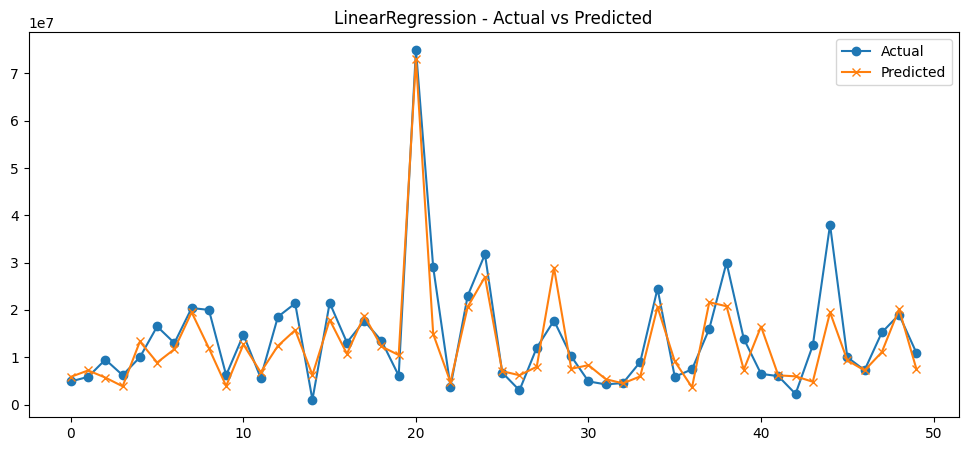


Training: Ridge
R2 Train: 0.6207
R2 Test : 0.6714
RMSE Test: 13679619.3972


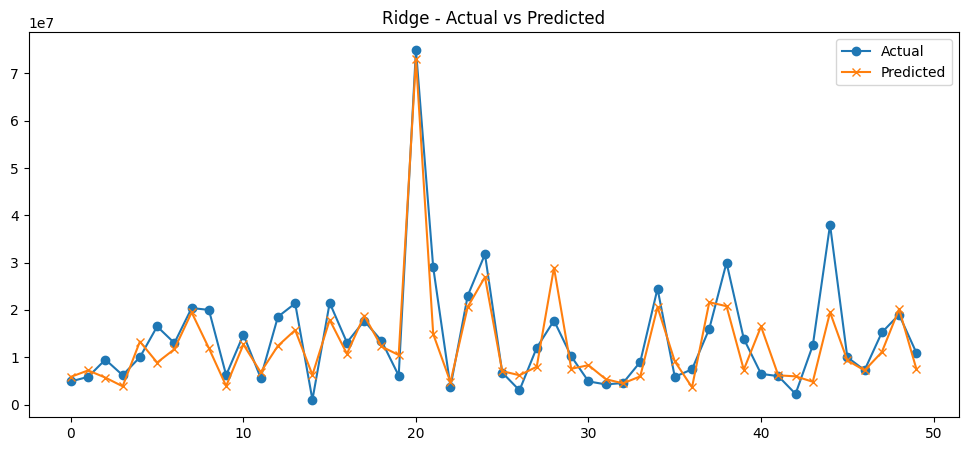


Training: PassiveAggressiveRegressor
R2 Train: 0.2528
R2 Test : 0.2661
RMSE Test: 20445199.8524


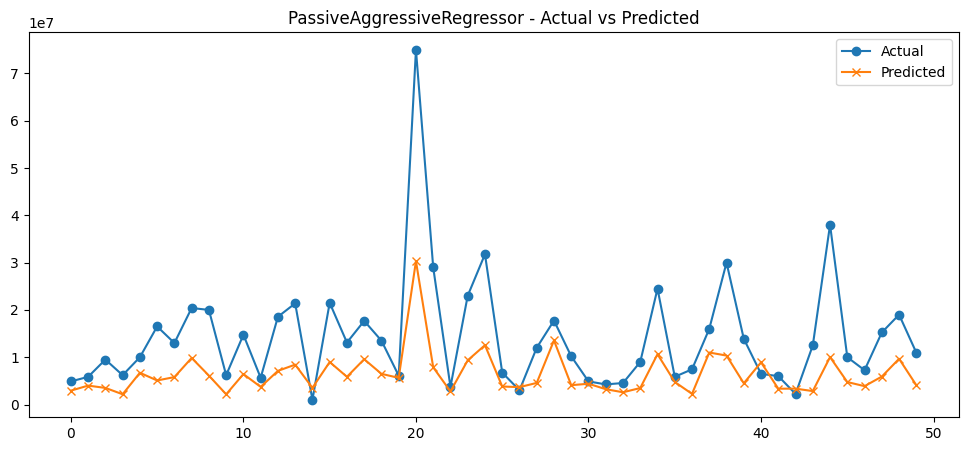


Training: DecisionTreeRegressor
R2 Train: 0.9964
R2 Test : 0.6067
RMSE Test: 14967664.2621


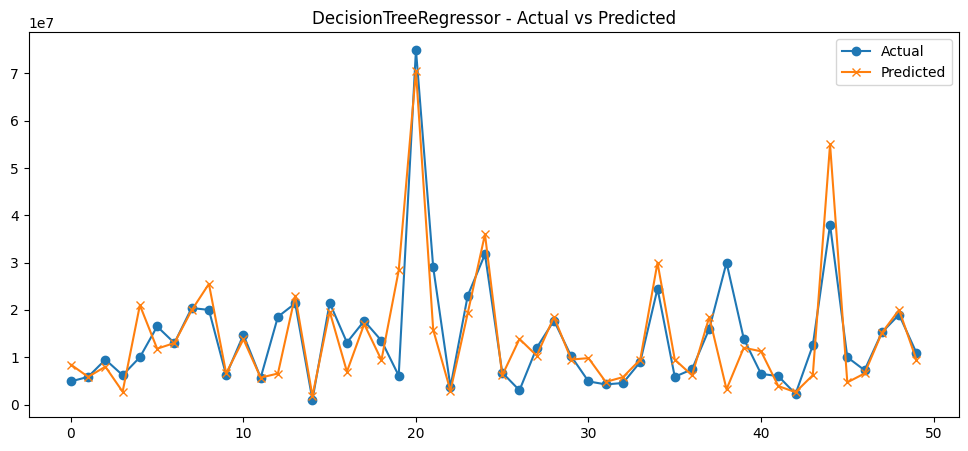


Training: RandomForestRegressor
R2 Train: 0.9538
R2 Test : 0.7273
RMSE Test: 12462675.5294


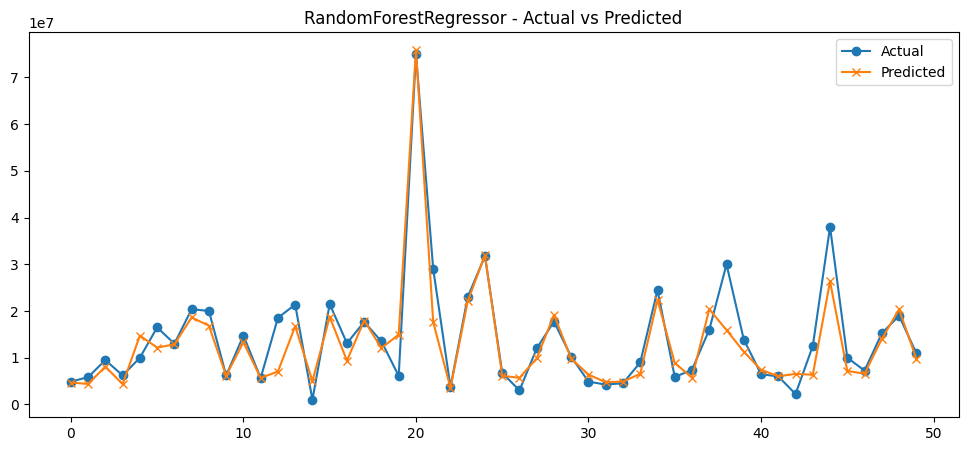


Training: AdaBoostRegressor
R2 Train: 0.5121
R2 Test : 0.4338
RMSE Test: 17957842.4533


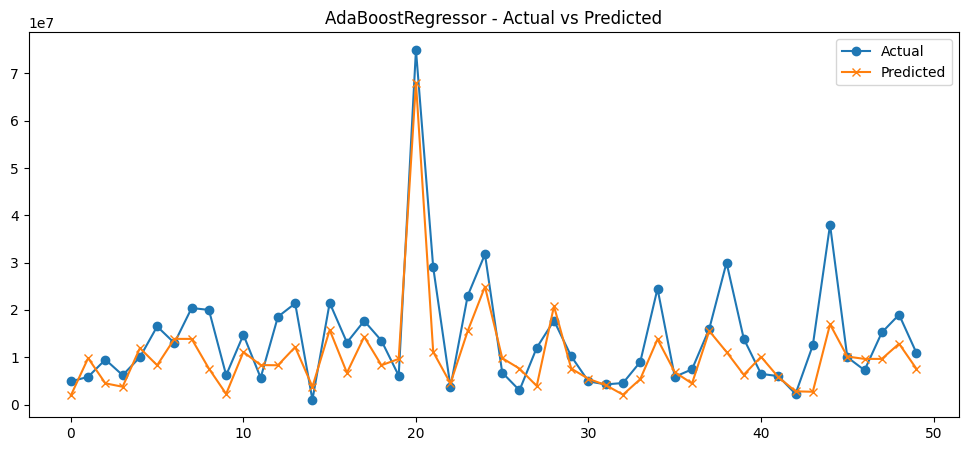


Training: GradientBoostingRegressor
R2 Train: 0.7701
R2 Test : 0.7197
RMSE Test: 12635790.9965


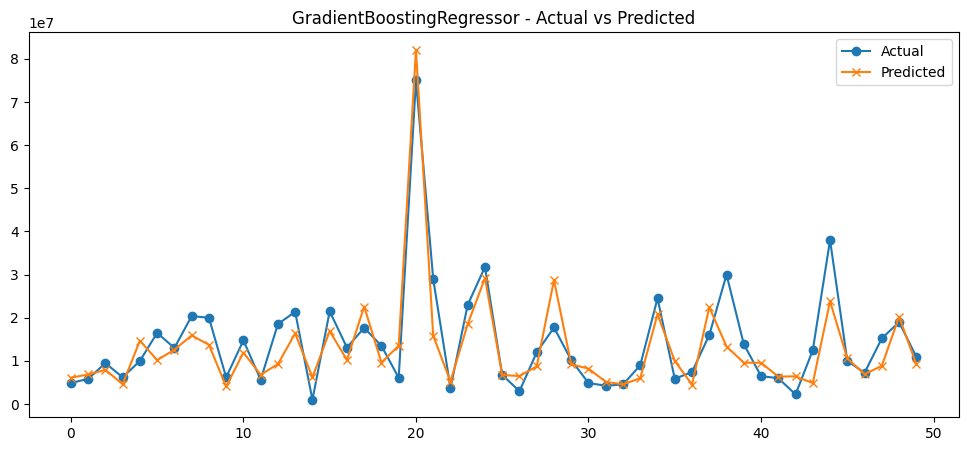


Training: ExtraTreesRegressor
R2 Train: 0.9964
R2 Test : 0.7517
RMSE Test: 11892993.8309


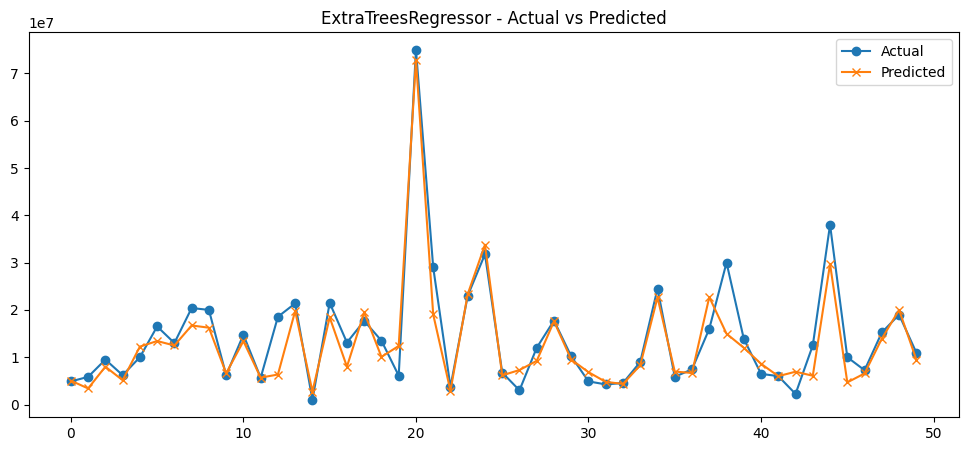


Training: XGBRegressor
R2 Train: 0.9350
R2 Test : 0.7947
RMSE Test: 10812807.6408


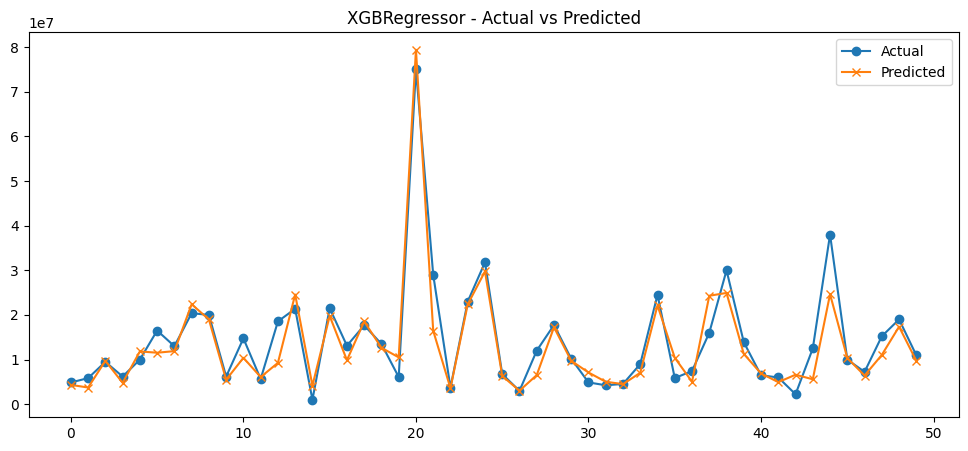


Training: LGBMRegressor
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000751 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1922
[LightGBM] [Info] Number of data points in the train set: 10034, number of used features: 17
[LightGBM] [Info] Start training from score 16.139114
R2 Train: 0.8361
R2 Test : 0.7668
RMSE Test: 11524588.9829


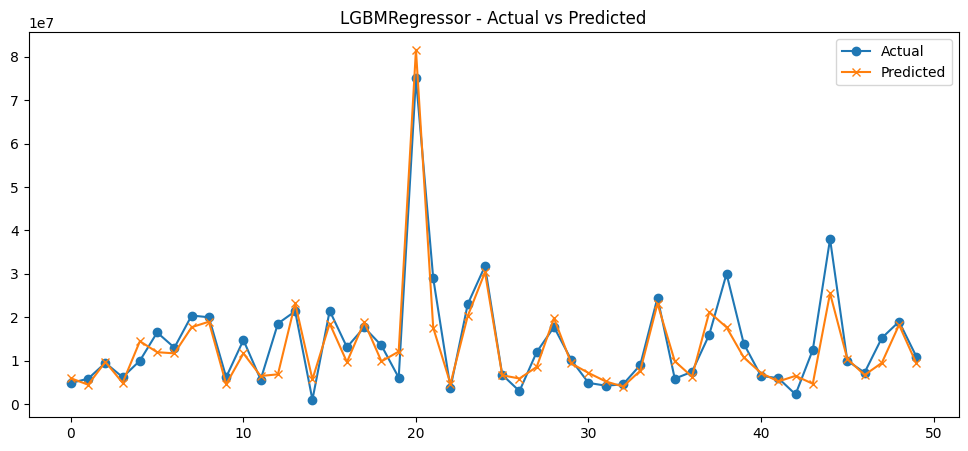


Training: CatBoostRegressor
R2 Train: 0.8866
R2 Test : 0.8072
RMSE Test: 10478034.2316


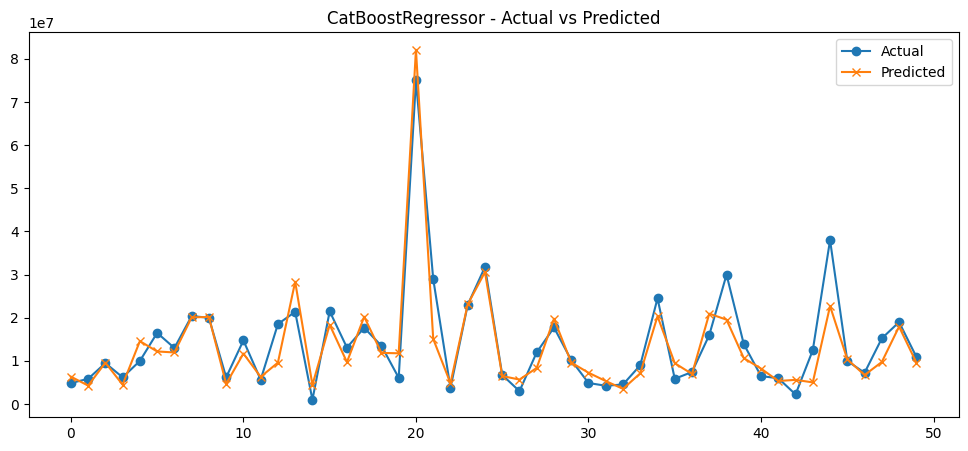


Training: KNeighborsRegressor
R2 Train: 0.7861
R2 Test : 0.6279
RMSE Test: 14558195.0958


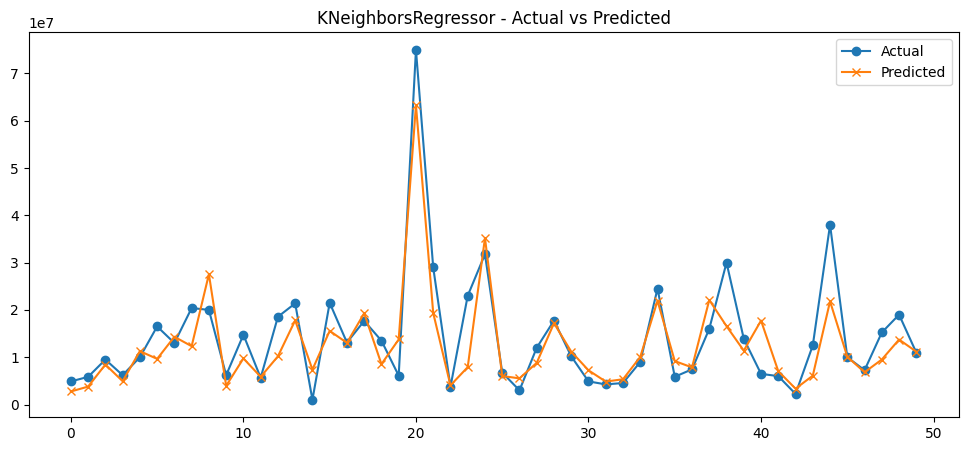


Training: SVR
R2 Train: 0.6721
R2 Test : 0.6972
RMSE Test: 13131819.7332


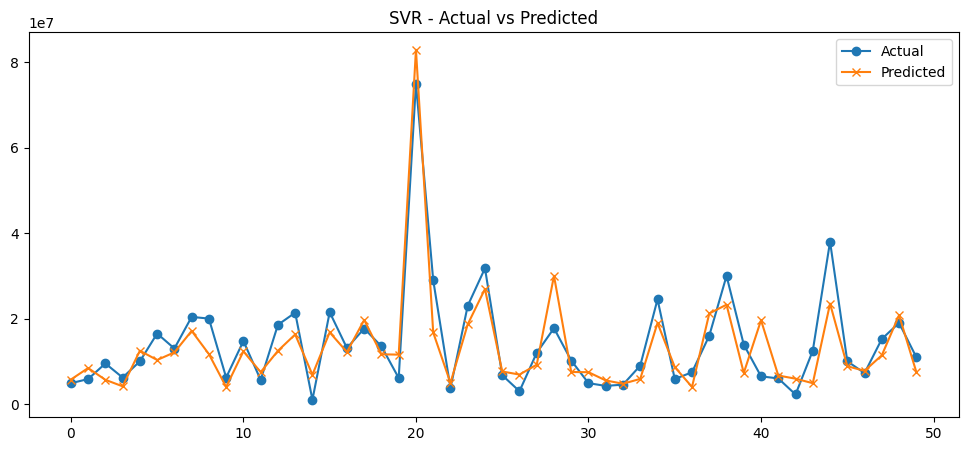


Training: LinearSVR
R2 Train: 0.6336
R2 Test : 0.6691
RMSE Test: 13728690.4240


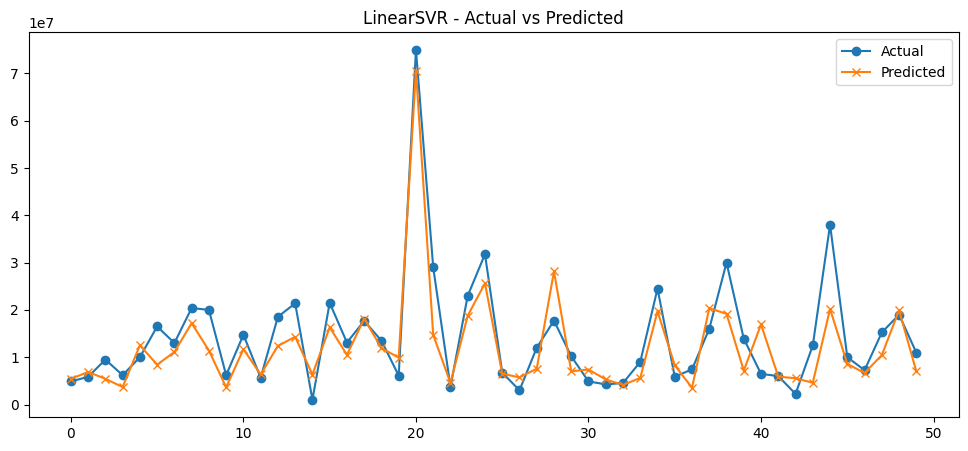


Training: MLPRegressor
R2 Train: 0.6600
R2 Test : 0.7549
RMSE Test: 11814341.1974


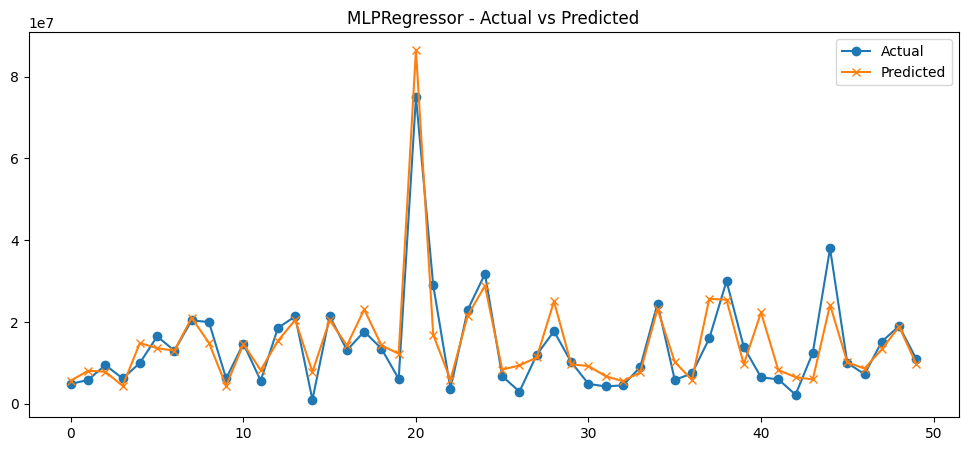

In [66]:
results = []

for name, model in models:
    print(f"\n{'='*50}")
    print(f"Training: {name}")

    # Wrap the model with TransformedTargetRegressor
    wrapped_model = TransformedTargetRegressor(
        regressor=Modelmaker(model=model),
        func=np.log1p,
        inverse_func=np.expm1
    )

    # fit - pass original y (no manual transform)
    wrapped_model.fit(X_train, y_train)

    # predict - returns inverse‑transformed predictions automatically
    y_train_pred = wrapped_model.predict(X_train)
    y_test_pred  = wrapped_model.predict(X_test)

    # Metrics - directly compare with original y
    r2_train = r2_score(y_train, y_train_pred)
    r2_test  = r2_score(y_test, y_test_pred)
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

    print(f"R2 Train: {r2_train:.4f}")
    print(f"R2 Test : {r2_test:.4f}")
    print(f"RMSE Test: {rmse_test:.4f}")

    results.append((name, r2_test, rmse_test))

    # Plot - use original y_test and predictions directly
    plt.figure(figsize=(12,5))
    plt.plot(y_test.values[:50], label="Actual", marker="o")
    plt.plot(y_test_pred[:50], label="Predicted", marker="x")
    plt.title(f"{name} - Actual vs Predicted")
    plt.legend()
    plt.show()

In [67]:
results_df = pd.DataFrame(results, columns=['Model', 'R2_Test', 'RMSE_Test']).sort_values(by='R2_Test', ascending=False)
results_df

,Model,R2_Test,RMSE_Test
10,CatBoostRegressor,0.807234,1.047803e+07
8,XGBRegressor,0.794720,1.081281e+07
9,LGBMRegressor,0.766804,1.152459e+07
14,MLPRegressor,0.754931,1.181434e+07
7,ExtraTreesRegressor,0.751657,1.189299e+07
4,RandomForestRegressor,0.727295,1.246268e+07
6,GradientBoostingRegressor,0.719666,1.263579e+07
12,SVR,0.697225,1.313182e+07
1,Ridge,0.671437,1.367962e+07
0,LinearRegression,0.671137,1.368586e+07
